# Advanced Analyses — Climate Intelligence Report

This notebook presents the 5 advanced analysis requirements:
1. **Climate Analysis** — regional/hemispheric patterns
2. **Environmental Impact** — weather ↔ air quality
3. **Feature Importance** — 3 techniques compared
4. **Spatial Analysis** — geographical maps
5. **Geographical Patterns** — continental comparisons

In [ ]:
import os
import pandas as pd
from IPython.display import display, Image

FIGS = os.path.join('..', 'reports', 'figures')
REPORTS = os.path.join('..', 'reports')

---
# 1. Climate Analysis

**Objective:** Study long-term climate patterns and variations in different regions.

We segment the data by **hemisphere** (Northern vs Southern) and **climate zone** (Tropical, Subtropical, Temperate, Polar/Subpolar based on latitude bands).

---
## 1.1 Temperature Trends by Hemisphere

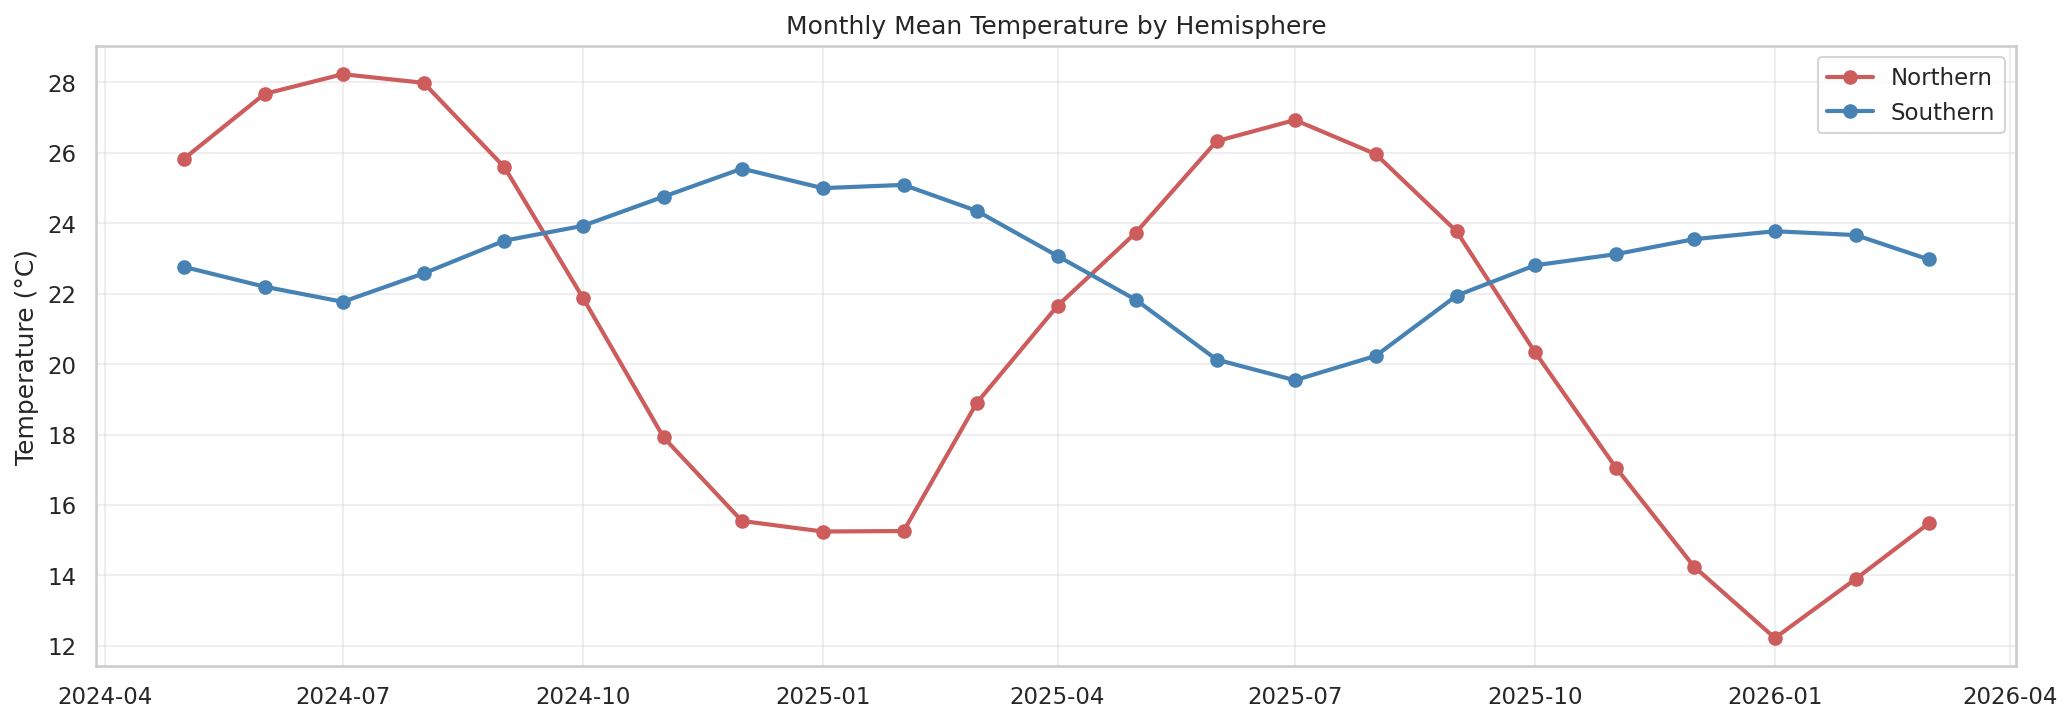

In [ ]:
display(Image(filename=os.path.join(FIGS, 'climate_hemisphere_trends.png')))

**Key insight:** The hemispheres show **opposite seasonal patterns** — when the Northern Hemisphere is in summer (peaks ~July), the Southern Hemisphere is in winter (troughs ~July). This is the expected physical behavior due to Earth's axial tilt.

The Northern Hemisphere shows **larger seasonal amplitude** because it contains more continental landmass (which heats/cools more dramatically than ocean).

---
## 1.2 Temperature by Climate Zone

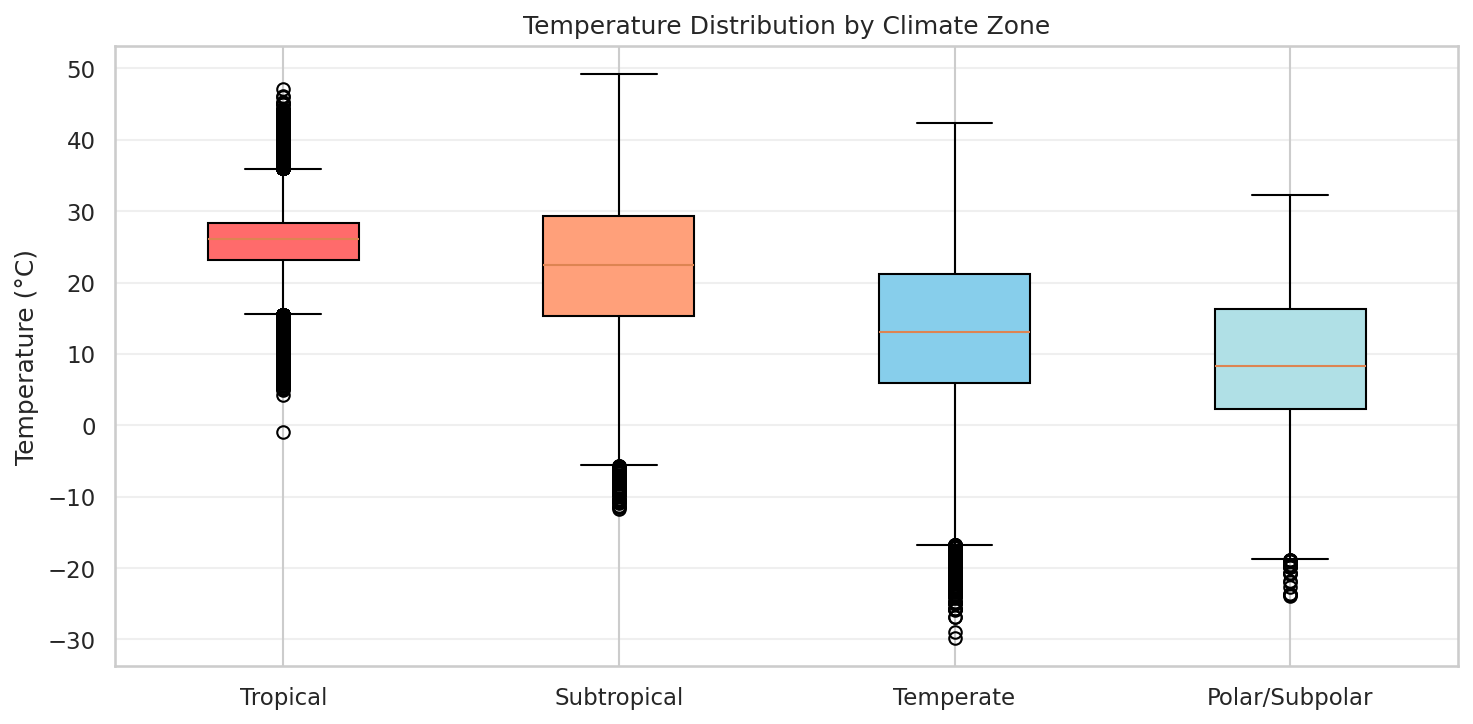

In [ ]:
display(Image(filename=os.path.join(FIGS, 'climate_zone_boxplot.png')))

| Zone | Mean Temp | Variability | Records |
|---|---|---|---|
| Tropical (0°–23.5°) | 25.5°C | Low (σ=4.8) | 65,396 |
| Subtropical (23.5°–40°) | 22.3°C | High (σ=9.9) | 30,804 |
| Temperate (40°–55°) | 13.5°C | Very high (σ=10.8) | 29,950 |
| Polar/Subpolar (>55°) | 9.0°C | High (σ=9.4) | 5,413 |

Tropical regions are **stable** (narrow box), while temperate/subtropical zones have wide seasonal swings.

---
## 1.3 Precipitation Trends by Hemisphere

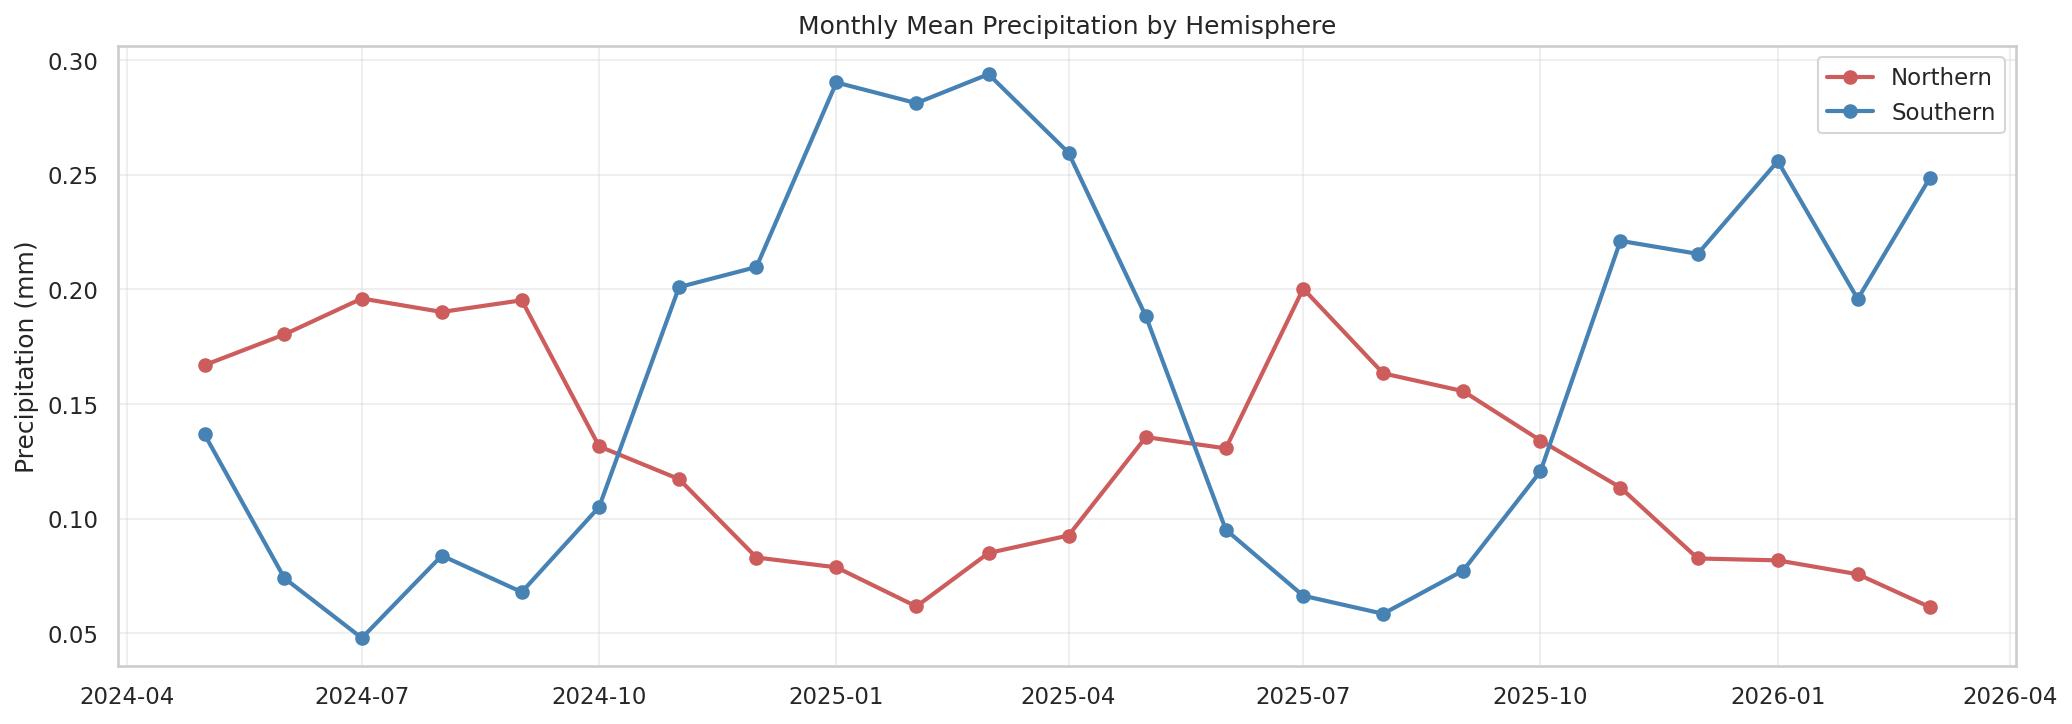

In [ ]:
display(Image(filename=os.path.join(FIGS, 'climate_hemisphere_precip.png')))

Precipitation patterns also differ by hemisphere, though with less dramatic seasonal amplitude than temperature.

---
# 2. Environmental Impact

**Objective:** Analyze air quality and its correlation with weather parameters.

---
## 2.1 Weather → Air Quality Correlations

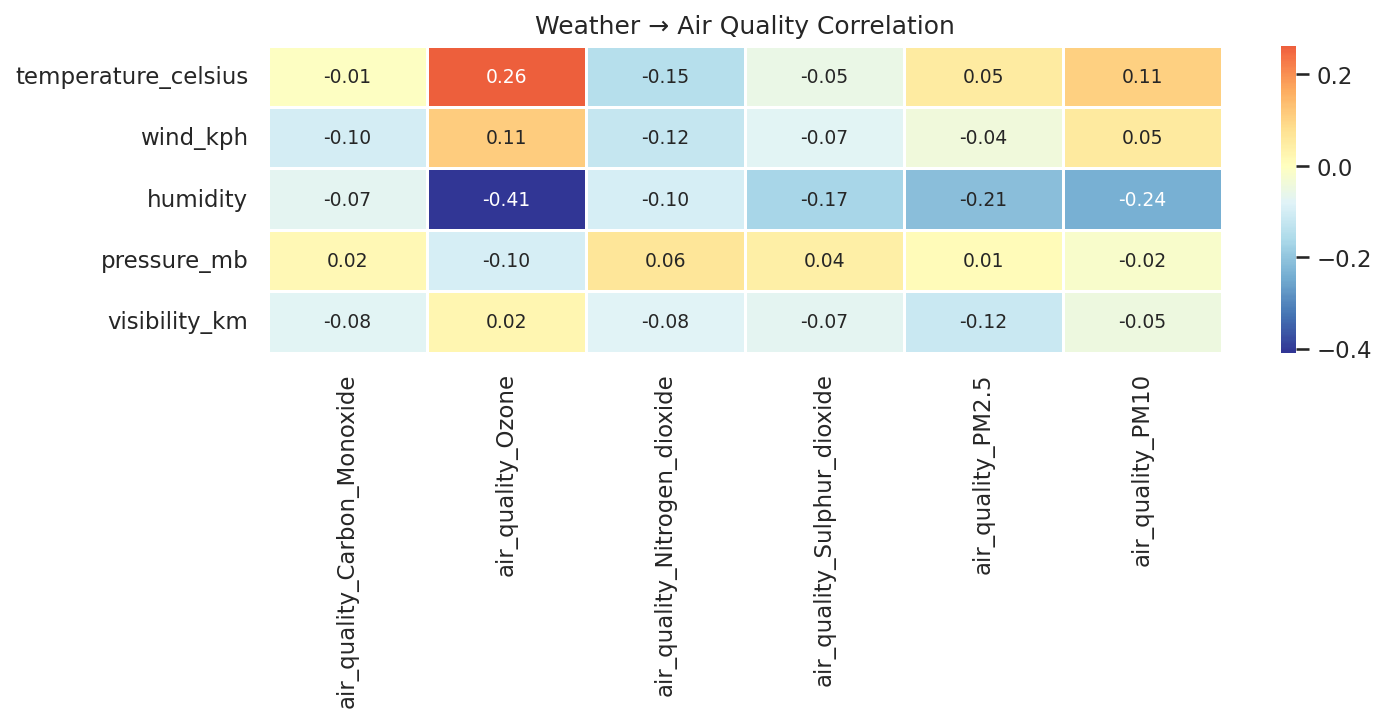

In [ ]:
display(Image(filename=os.path.join(FIGS, 'env_weather_airquality_corr.png')))

### Key correlations found:

| Weather → Pollutant | r | Physical explanation |
|---|---|---|
| Humidity → Ozone | −0.41 | **Strongest.** High humidity reduces UV penetration, suppressing ozone formation |
| Temperature → Ozone | +0.26 | Heat + UV drive photochemical ozone production |
| Humidity → PM2.5 | −0.21 | Humid air promotes particle settling (wet deposition) |
| Humidity → PM10 | −0.24 | Same mechanism, stronger for larger particles |
| Wind → CO | −0.10 | Wind disperses ground-level CO from traffic/industry |
| Wind → NO₂ | −0.12 | Wind disperses NO₂ from combustion sources |

---
## 2.2 Wind Speed and Pollutant Dispersion

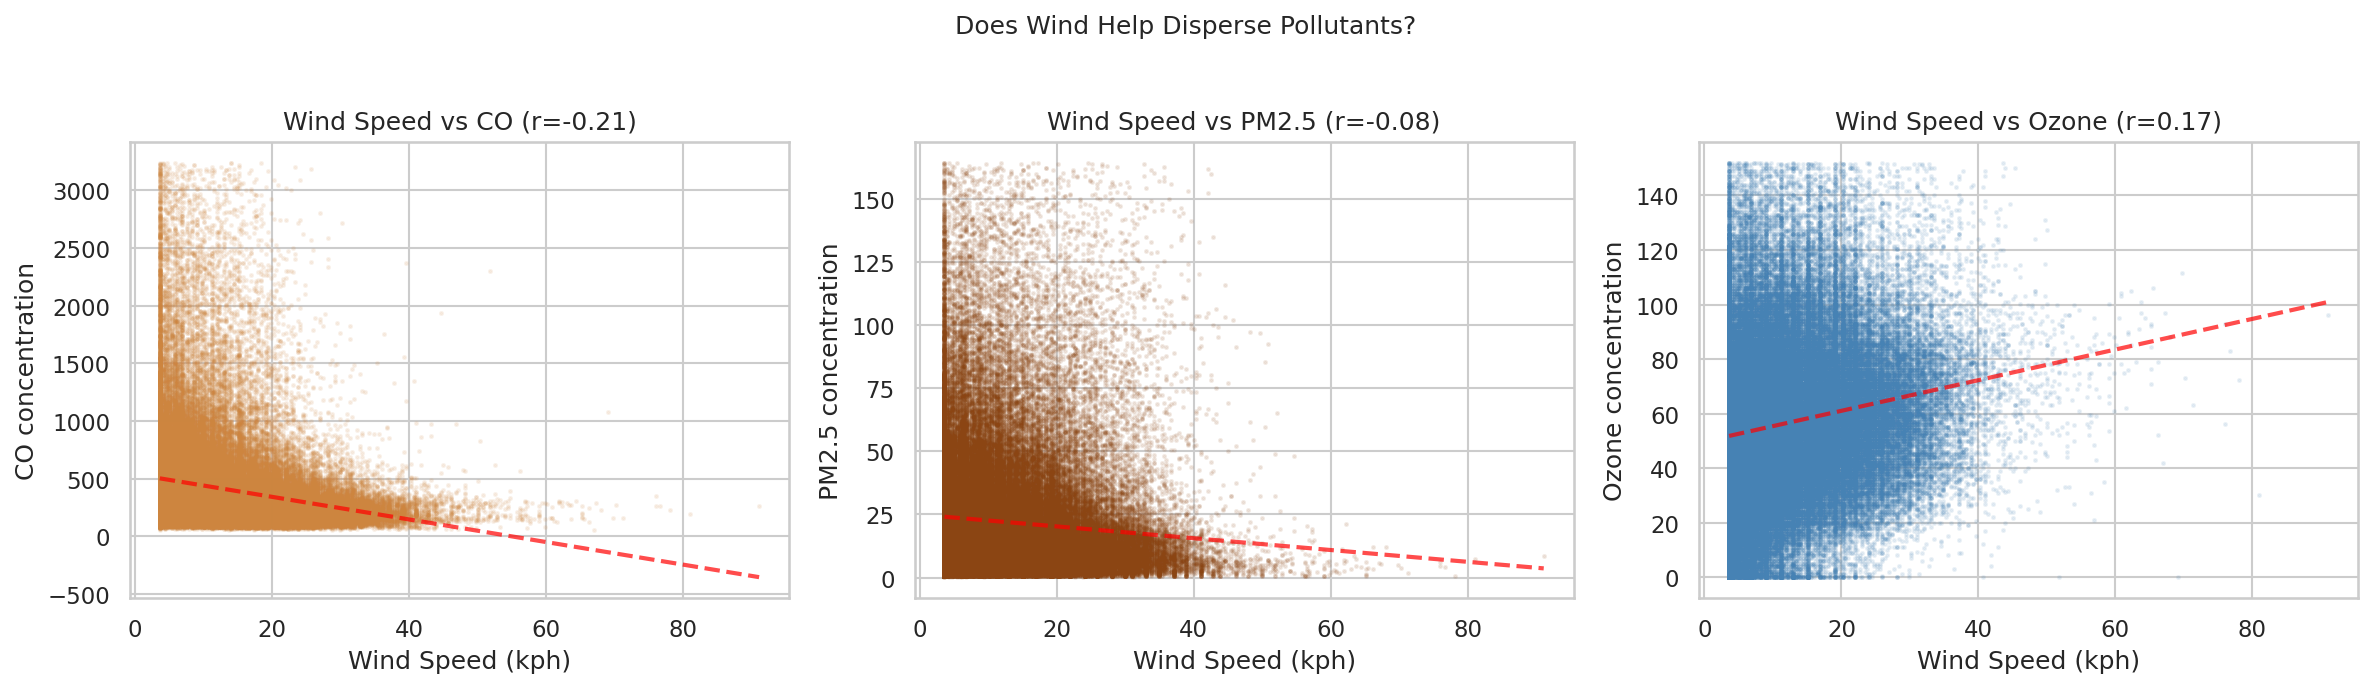

In [ ]:
display(Image(filename=os.path.join(FIGS, 'env_wind_dispersion.png')))

Wind speed shows a mild negative trend with CO and PM2.5 — higher wind disperses pollutants. But wind *increases* ozone, likely because wind brings precursor gases (NOx, VOCs) from industrial areas and increases mixing.

---
## 2.3 Temperature and Ozone

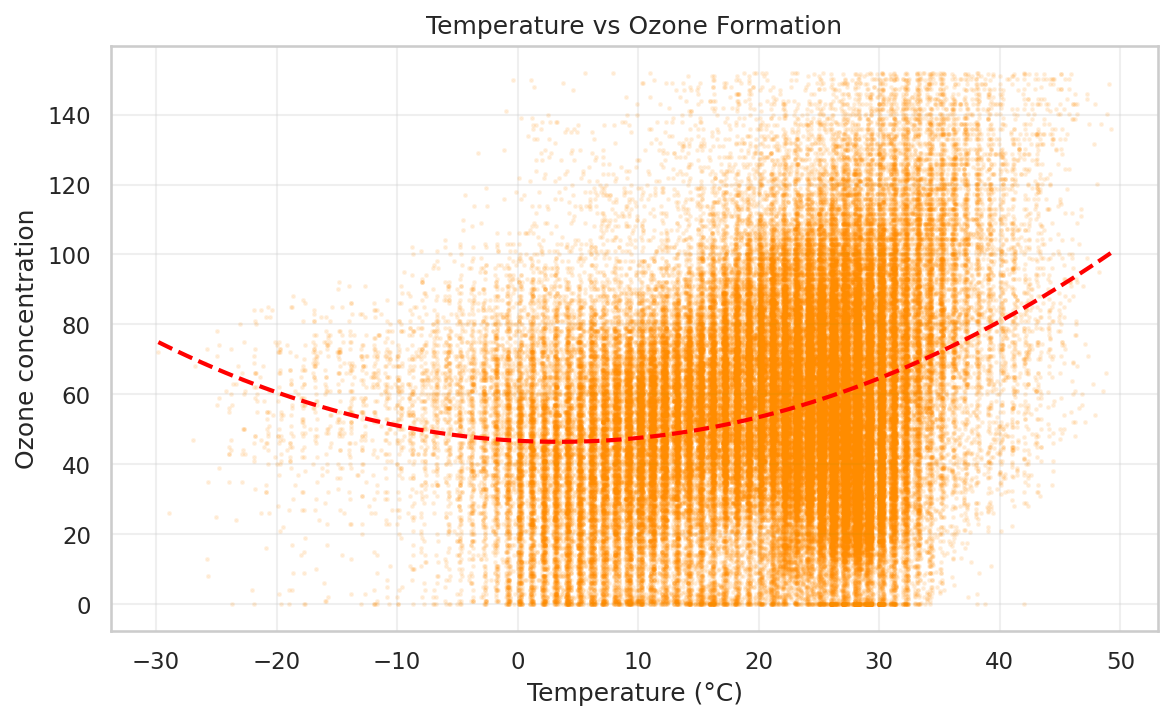

In [ ]:
display(Image(filename=os.path.join(FIGS, 'env_temp_ozone.png')))

Ozone shows a clear **quadratic** relationship with temperature — ozone production accelerates above ~25°C due to increased photochemical reaction rates. This has direct public health implications: hot days = high ozone = respiratory risk.

---
## 2.4 Air Quality by Climate Zone

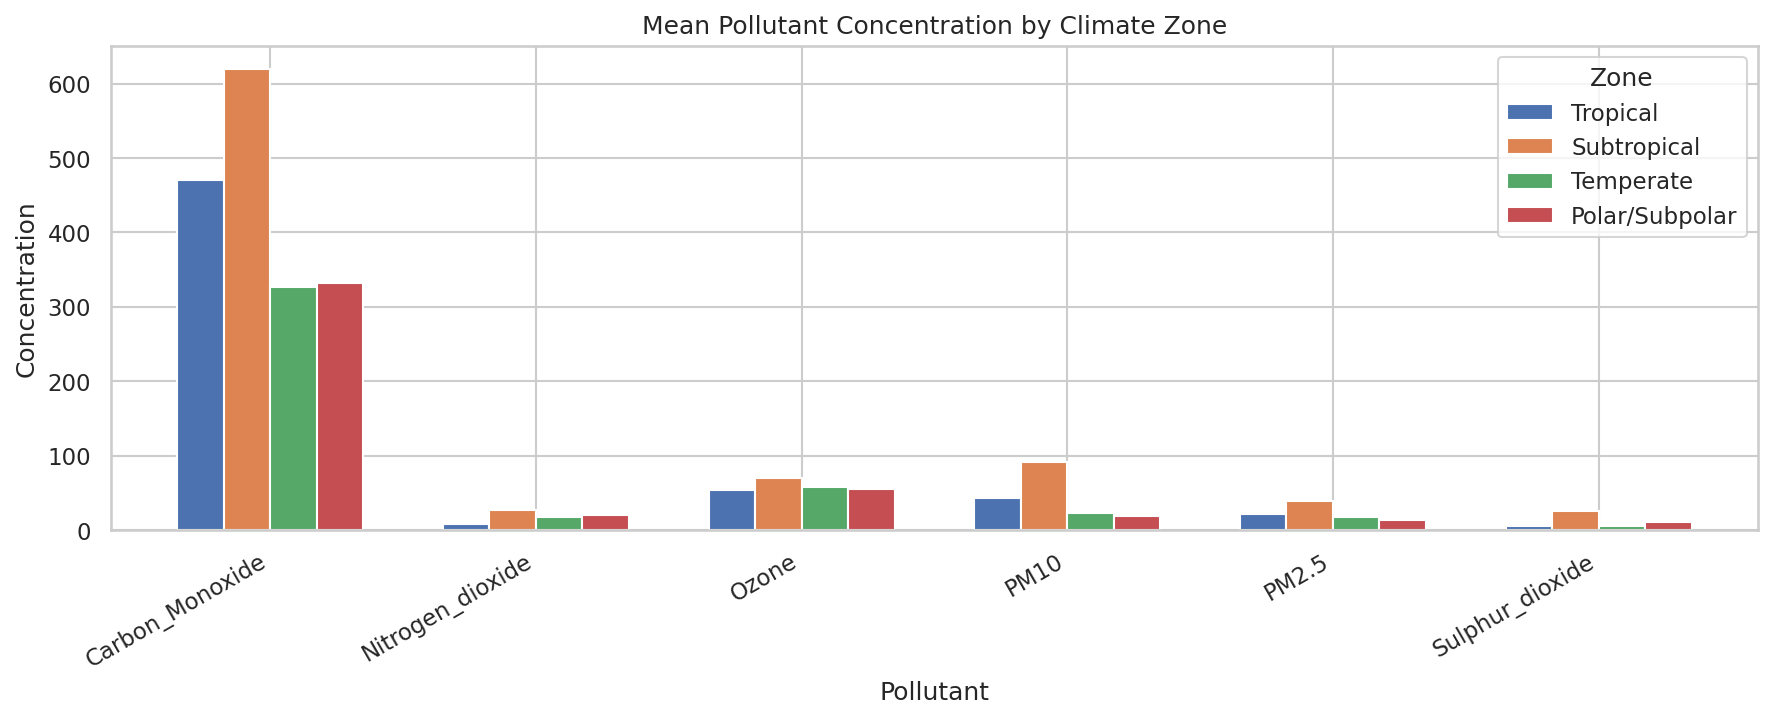

In [ ]:
display(Image(filename=os.path.join(FIGS, 'env_airquality_by_zone.png')))

Tropical and subtropical zones tend to have higher CO and PM levels — consistent with higher temperatures, less developed emission controls, and biomass burning.

---
# 3. Feature Importance

**Objective:** Apply different techniques to assess feature importance.

We compare **3 independent methods** to get a robust consensus:
1. **|r| Correlation** — simple linear relationship with temperature
2. **Gradient Boosting impurity** — how much each feature reduces loss in tree splits
3. **Permutation importance** — how much model accuracy drops when each feature is shuffled

---
## 3.1 Three Methods Compared

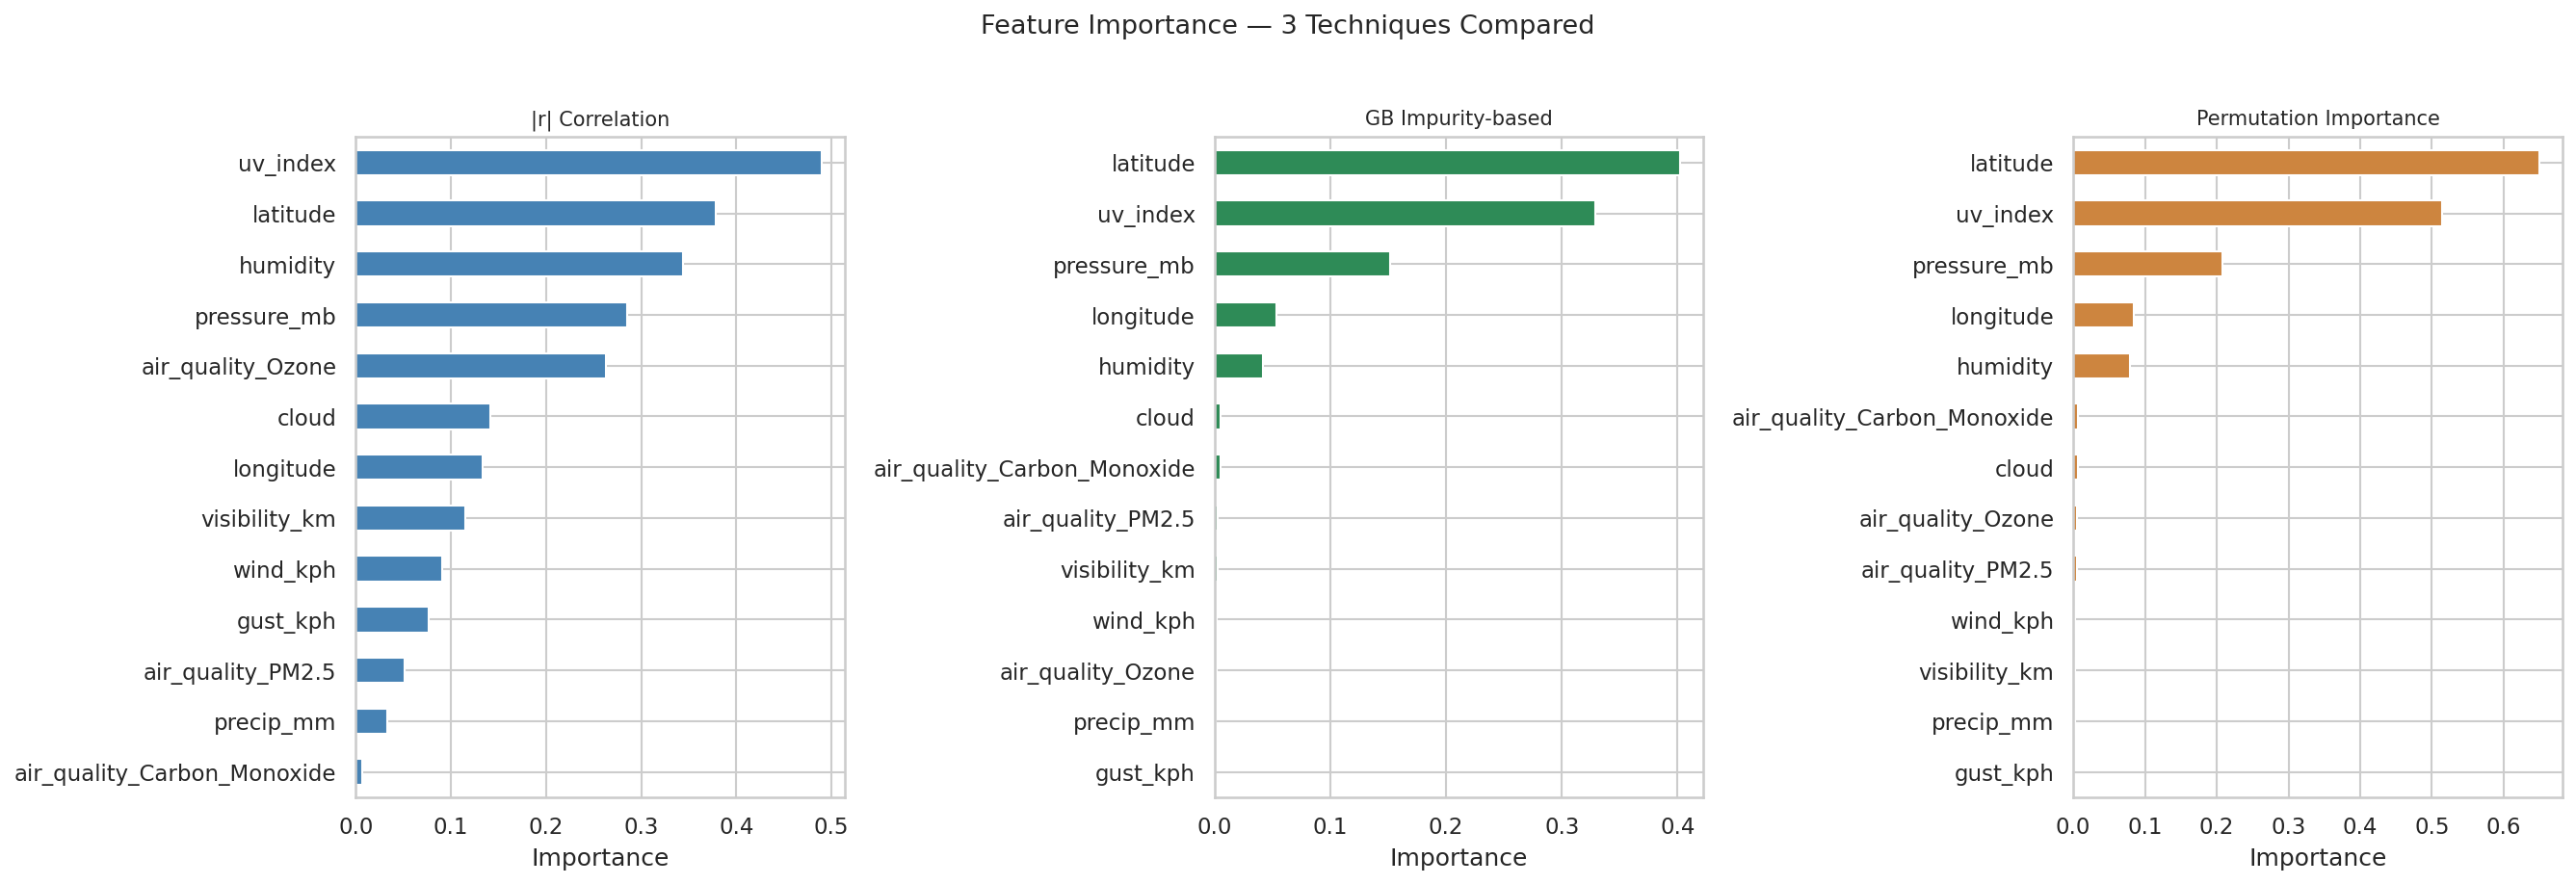

In [ ]:
display(Image(filename=os.path.join(FIGS, 'feature_importance_3methods.png')))

---
## 3.2 Consensus Ranking

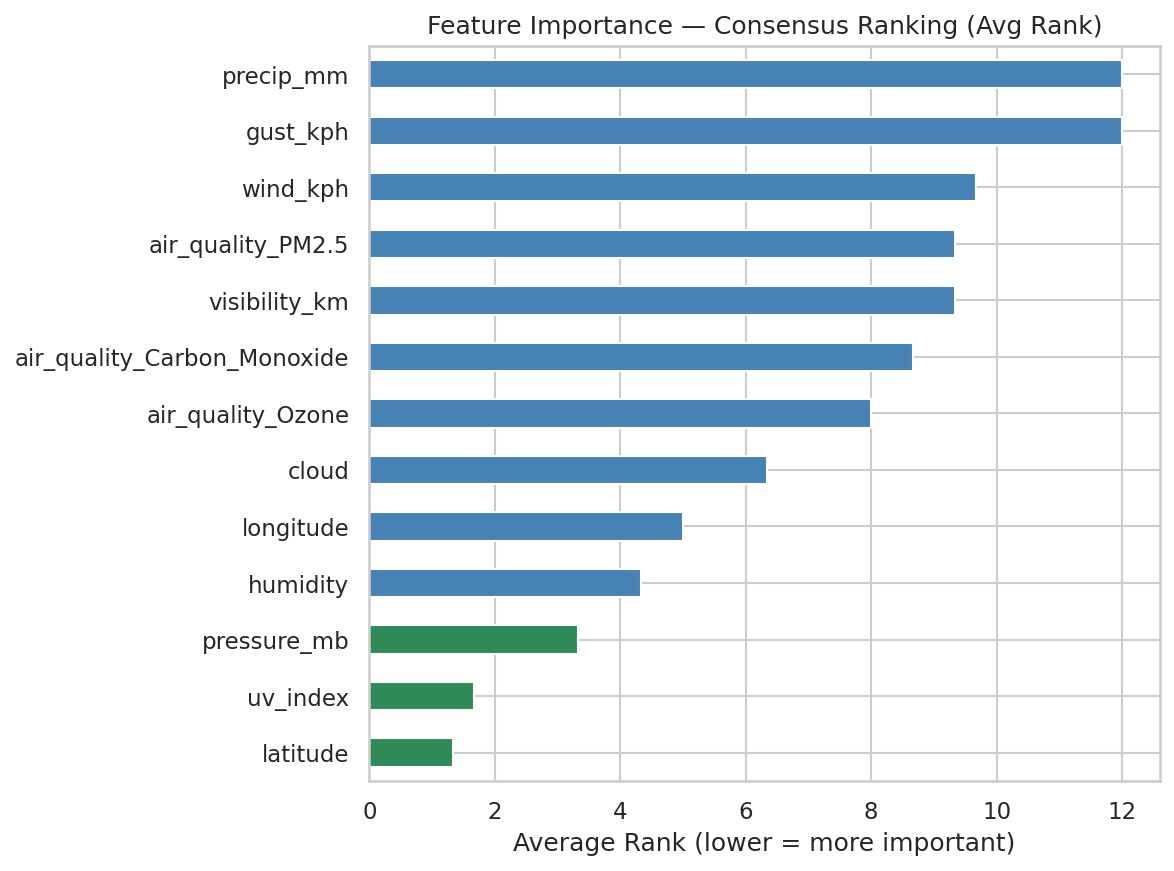

In [ ]:
display(Image(filename=os.path.join(FIGS, 'feature_importance_consensus.png')))

### Consensus Results

| Rank | Feature | Why? |
|---|---|---|
| 1 | **latitude** | Direct physical driver — equatorial = hotter |
| 2 | **uv_index** | Proxy for solar radiation intensity |
| 3 | **pressure_mb** | Related to altitude and weather systems |
| 4 | **humidity** | Inversely affects perceived and actual temperature |
| 5 | longitude | Captures continental vs maritime effects |

**Key insight:** Geography (latitude) is the single most important predictor of temperature — more important than any weather variable. This validates our choice to include lat/lon in the analysis.

---
# 4. Spatial Analysis

**Objective:** Analyze and visualize geographical patterns in the data.

---
## 4.1 Global Temperature Map

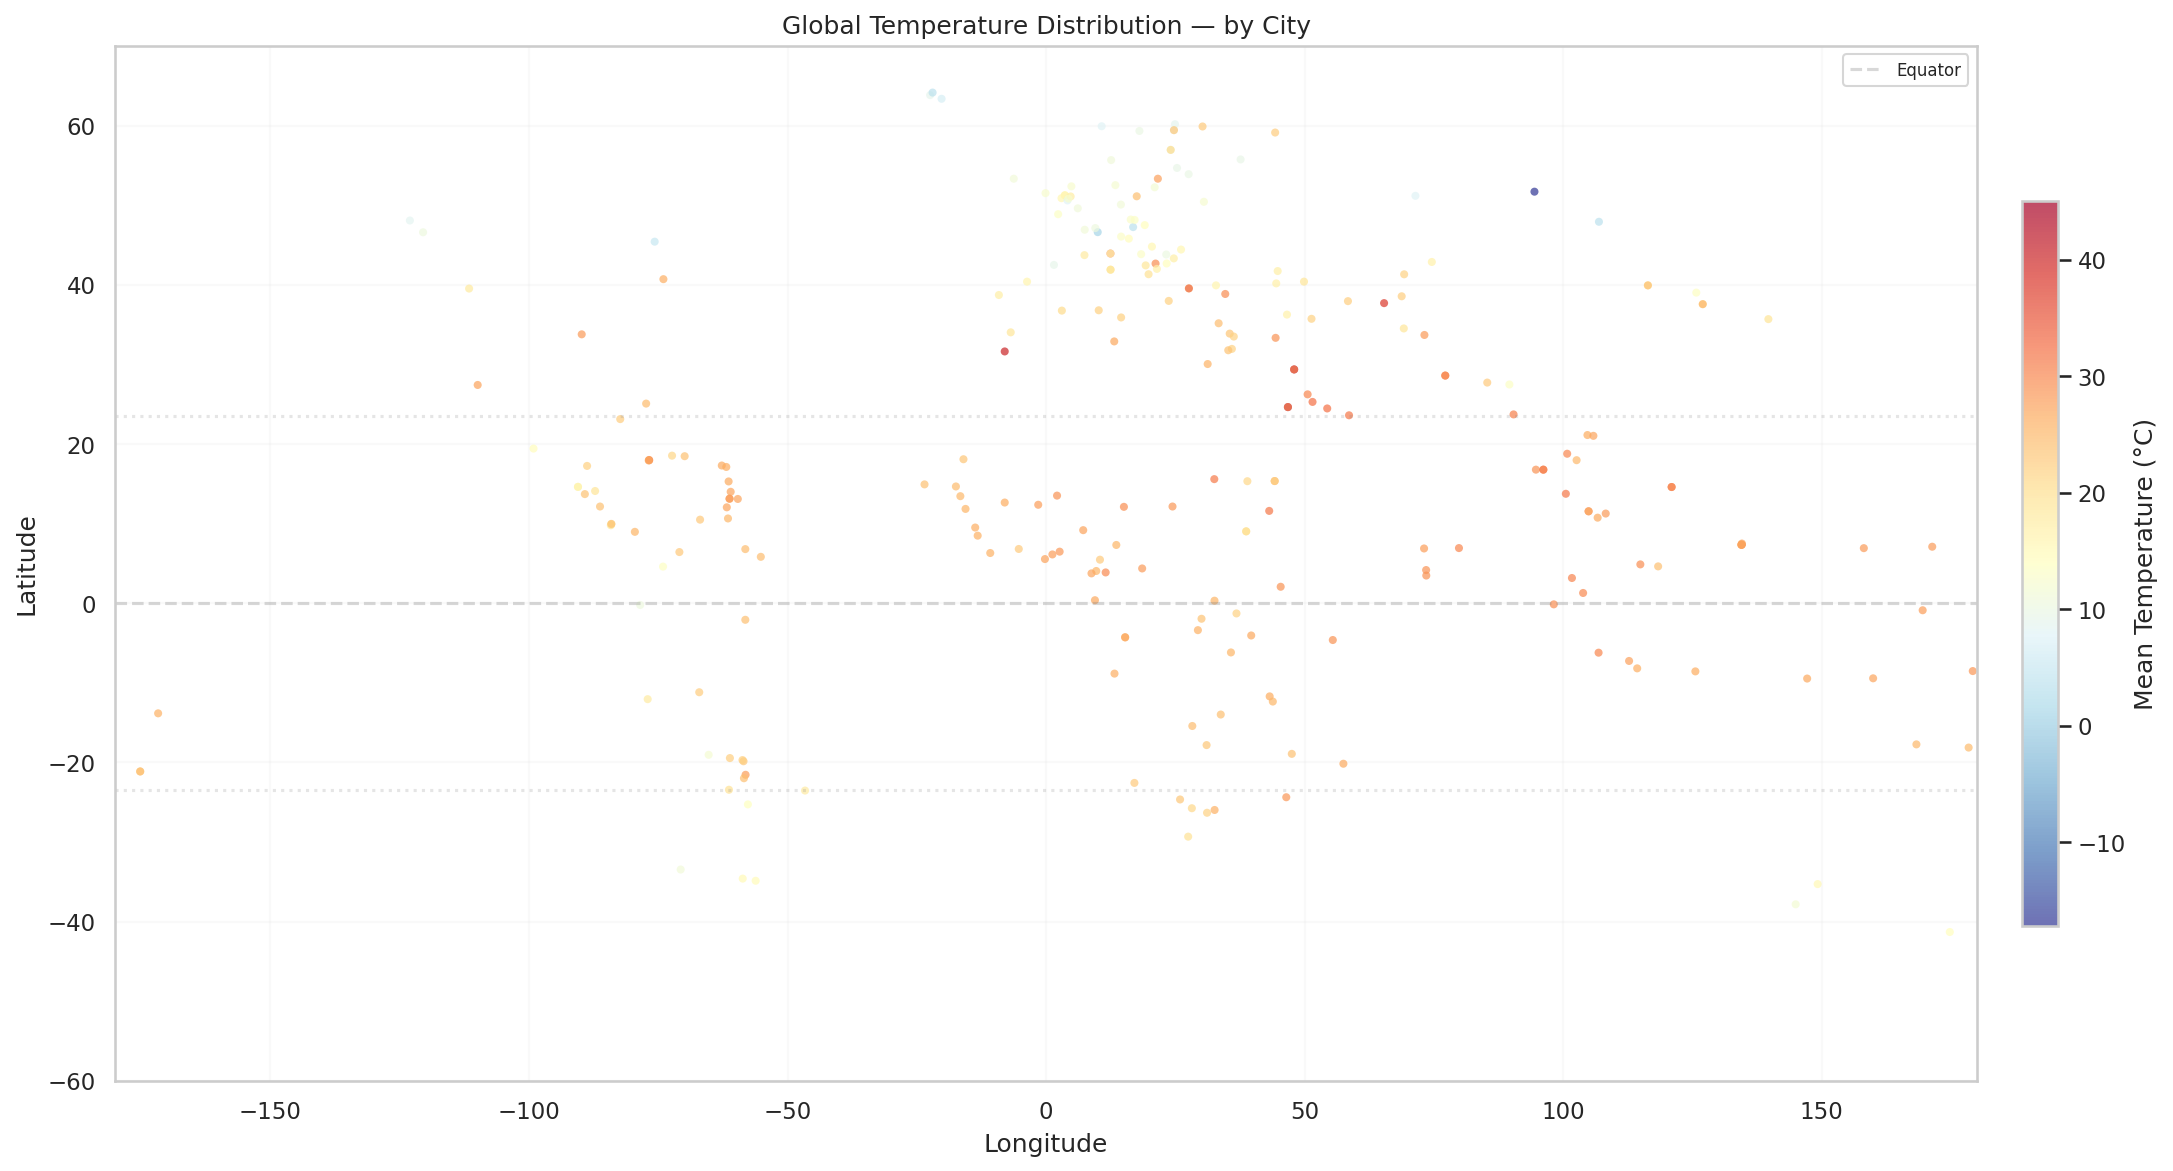

In [ ]:
display(Image(filename=os.path.join(FIGS, 'spatial_temperature_map.png')))

The scatter-map confirms the latitude→temperature gradient: equatorial cities (red) cluster around the tropics, cold cities (blue) at high latitudes. Longitude effects are visible too — continental interiors tend to be more extreme than coasts.

---
## 4.2 Global PM2.5 Map

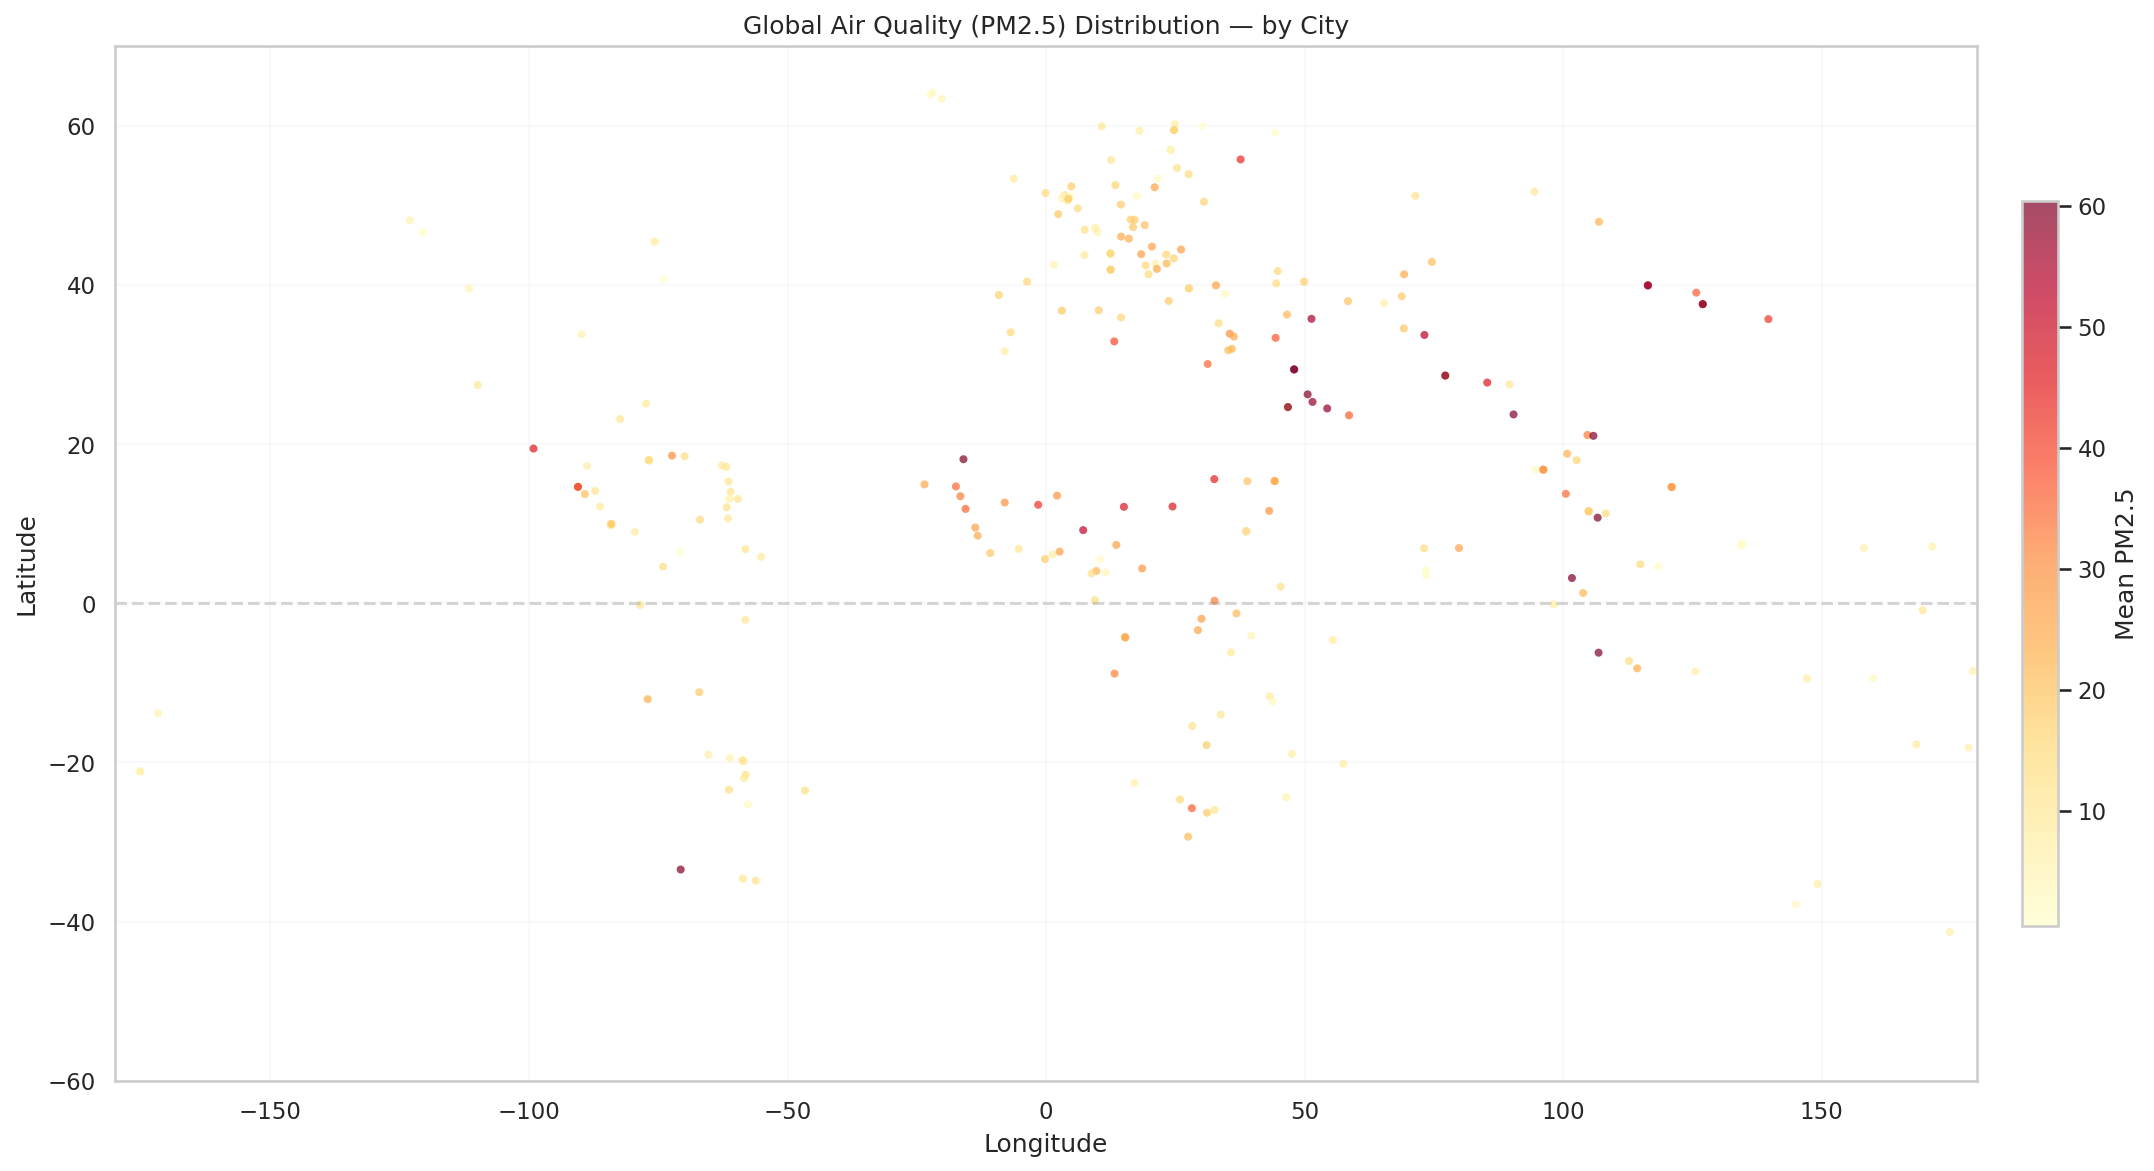

In [ ]:
display(Image(filename=os.path.join(FIGS, 'spatial_pm25_map.png')))

PM2.5 hotspots are concentrated in **South/Southeast Asia** and parts of **Africa** — regions with high industrial activity, biomass burning, and sometimes sandstorms.

---
## 4.3 Weather by Latitude Band

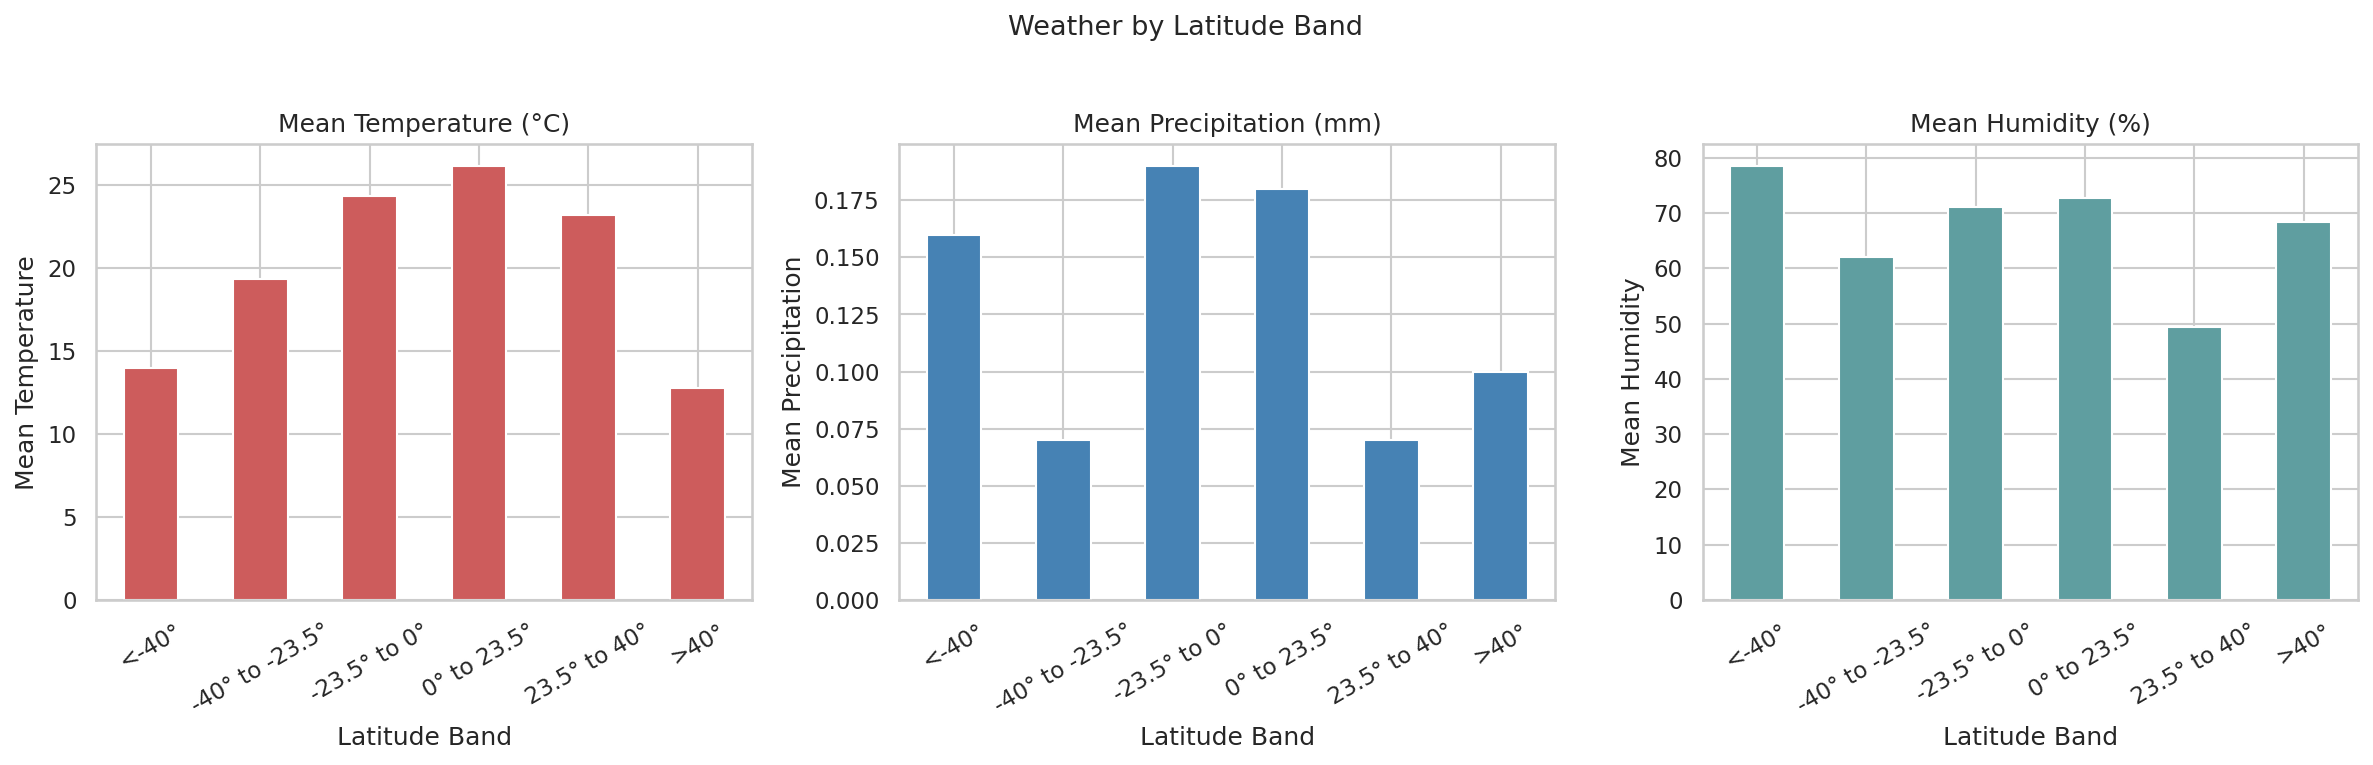

In [ ]:
display(Image(filename=os.path.join(FIGS, 'spatial_latitude_bands.png')))

Clear latitudinal gradient for temperature and humidity. Precipitation peaks near the equator (ITCZ — Intertropical Convergence Zone).

---
# 5. Geographical Patterns

**Objective:** Explore how weather conditions differ across countries and continents.

---
## 5.1 Temperature by Continent

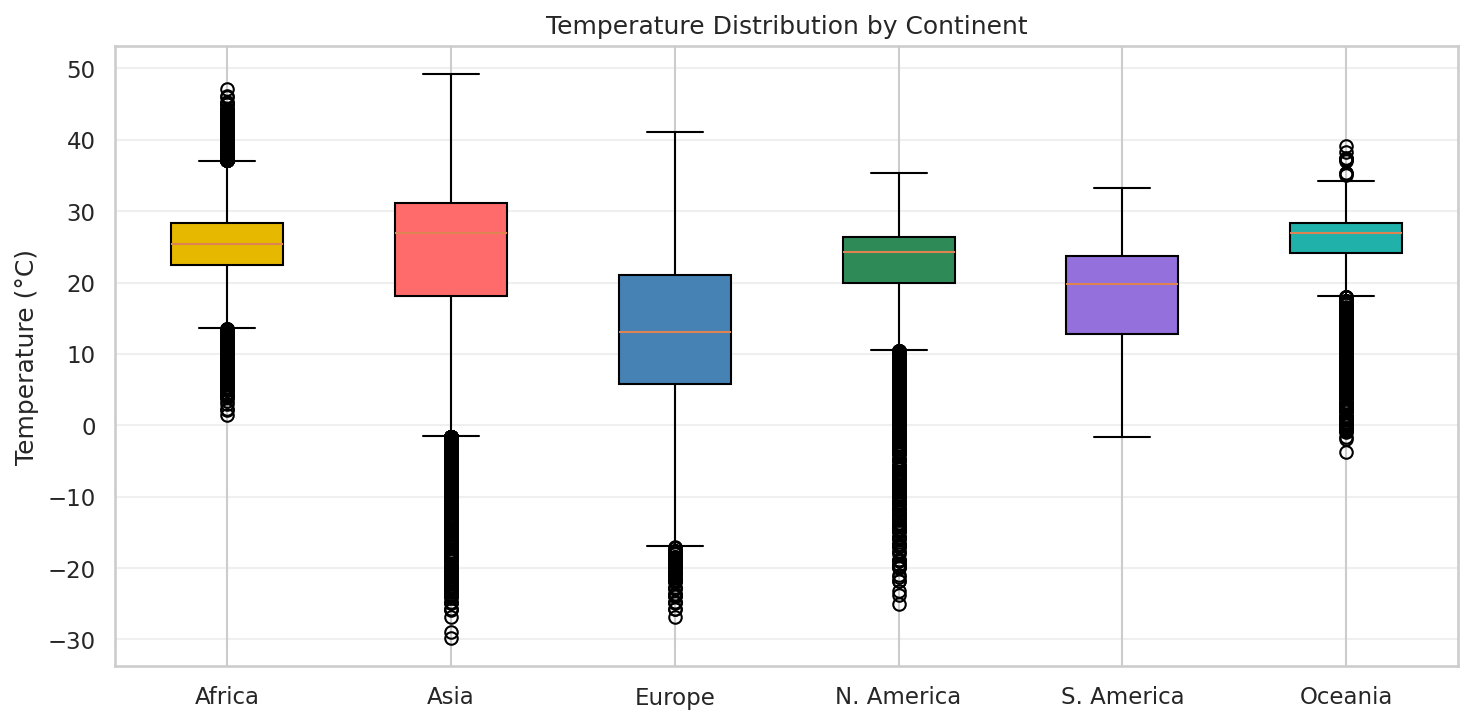

In [ ]:
display(Image(filename=os.path.join(FIGS, 'geo_temp_by_continent.png')))

| Continent | Mean Temp | Countries | Cities |
|---|---|---|---|
| Africa | 25.4°C | 48 | 55 |
| Oceania | 24.9°C | 12 | 17 |
| Asia | 24.0°C | 43 | 60 |
| N. America | 22.3°C | 23 | 29 |
| S. America | 18.4°C | 12 | 20 |
| Europe | 13.4°C | 44 | 56 |

Europe is the coldest continent by mean temperature, with the widest spread (most variability from Mediterranean to Scandinavia).

---
## 5.2 Air Quality by Continent

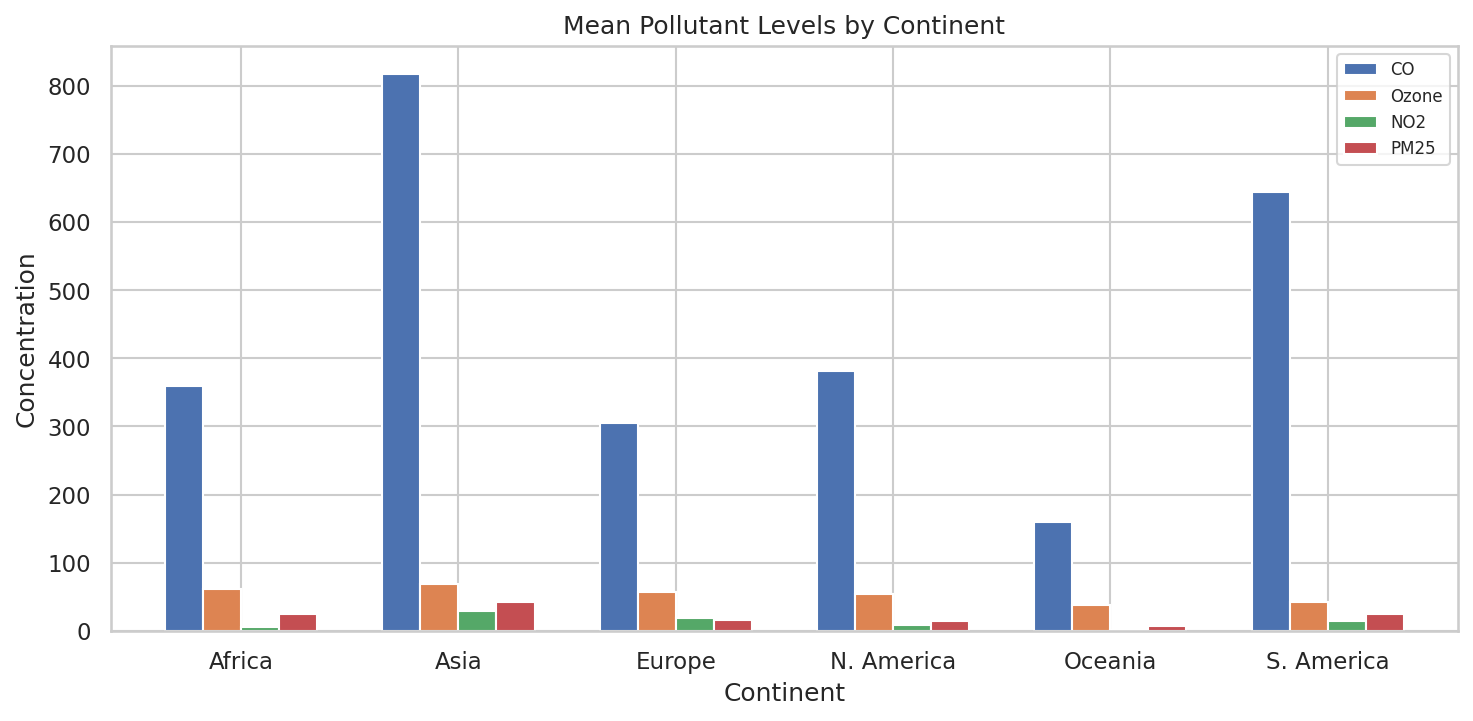

In [ ]:
display(Image(filename=os.path.join(FIGS, 'geo_airquality_by_continent.png')))

Asia shows the highest pollutant levels across all metrics, consistent with rapid industrialization and population density.

---
## 5.3 Monthly Trends by Continent

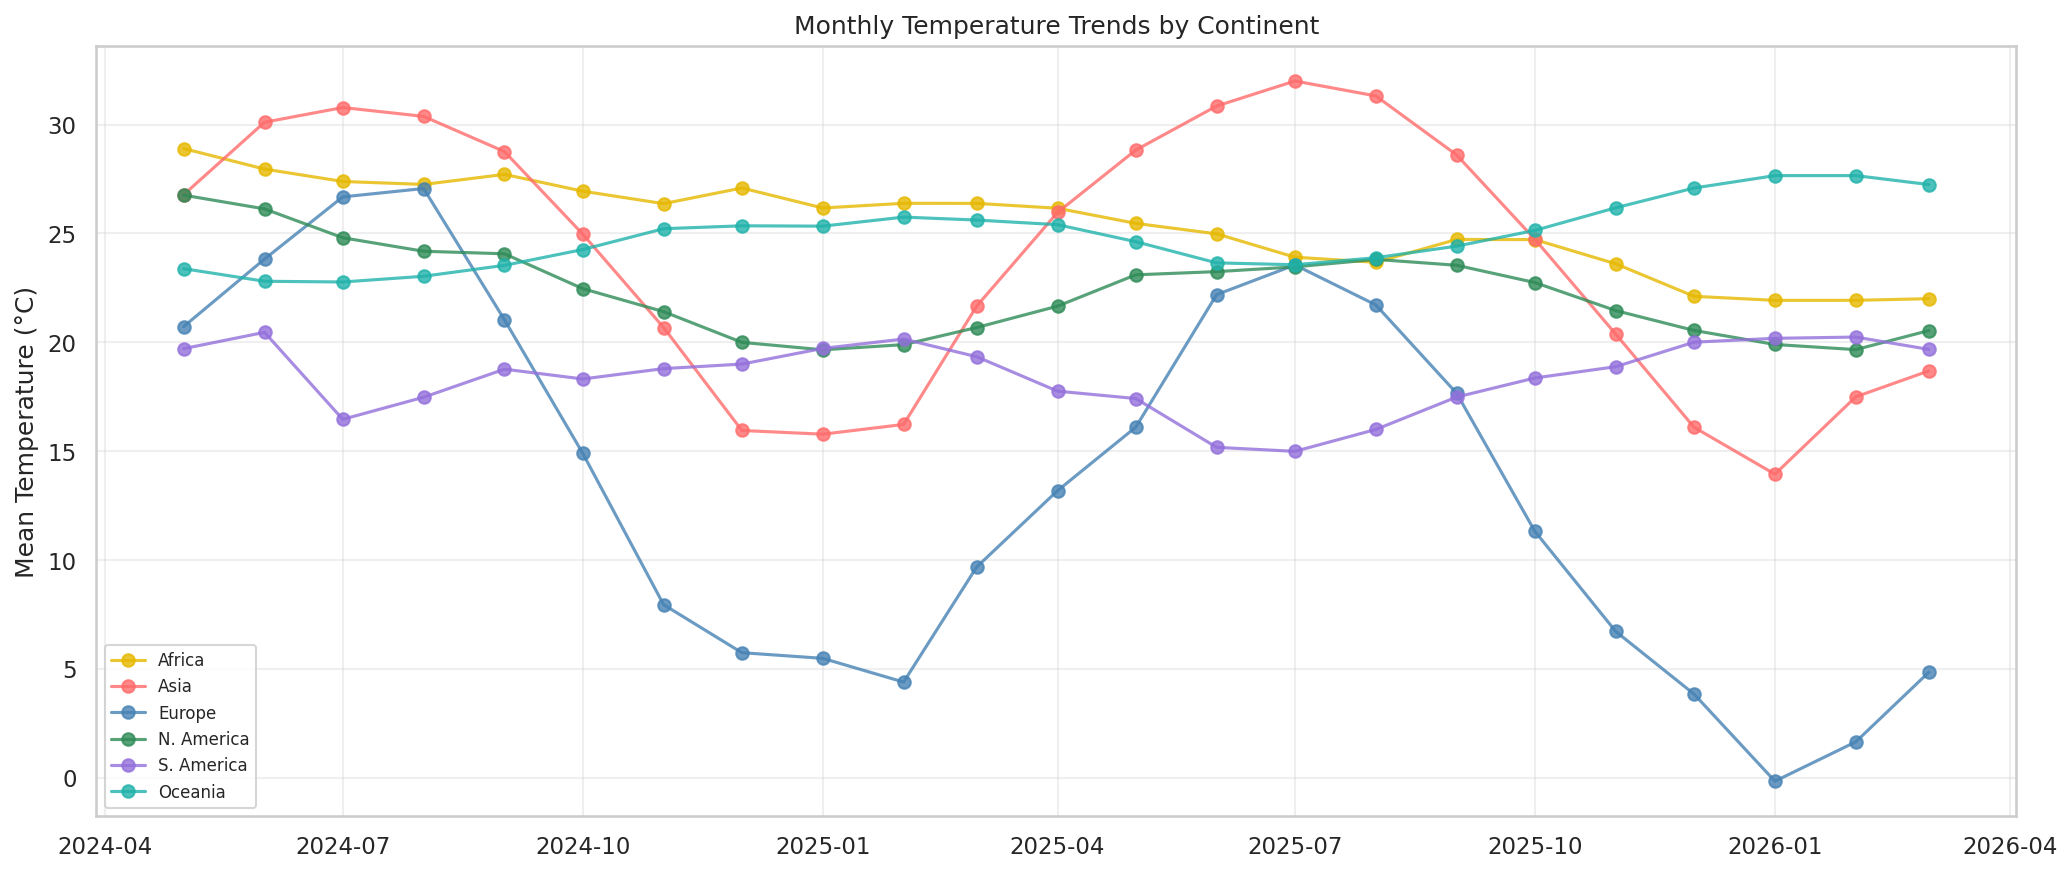

In [ ]:
display(Image(filename=os.path.join(FIGS, 'geo_continent_trends.png')))

The continental trends reveal **opposite seasonality** between Northern (Europe, N. America, Asia) and Southern (S. America, Oceania) hemisphere continents. Africa (mostly tropical) shows the least seasonal variation.

---
## 5.4 Extreme Cities

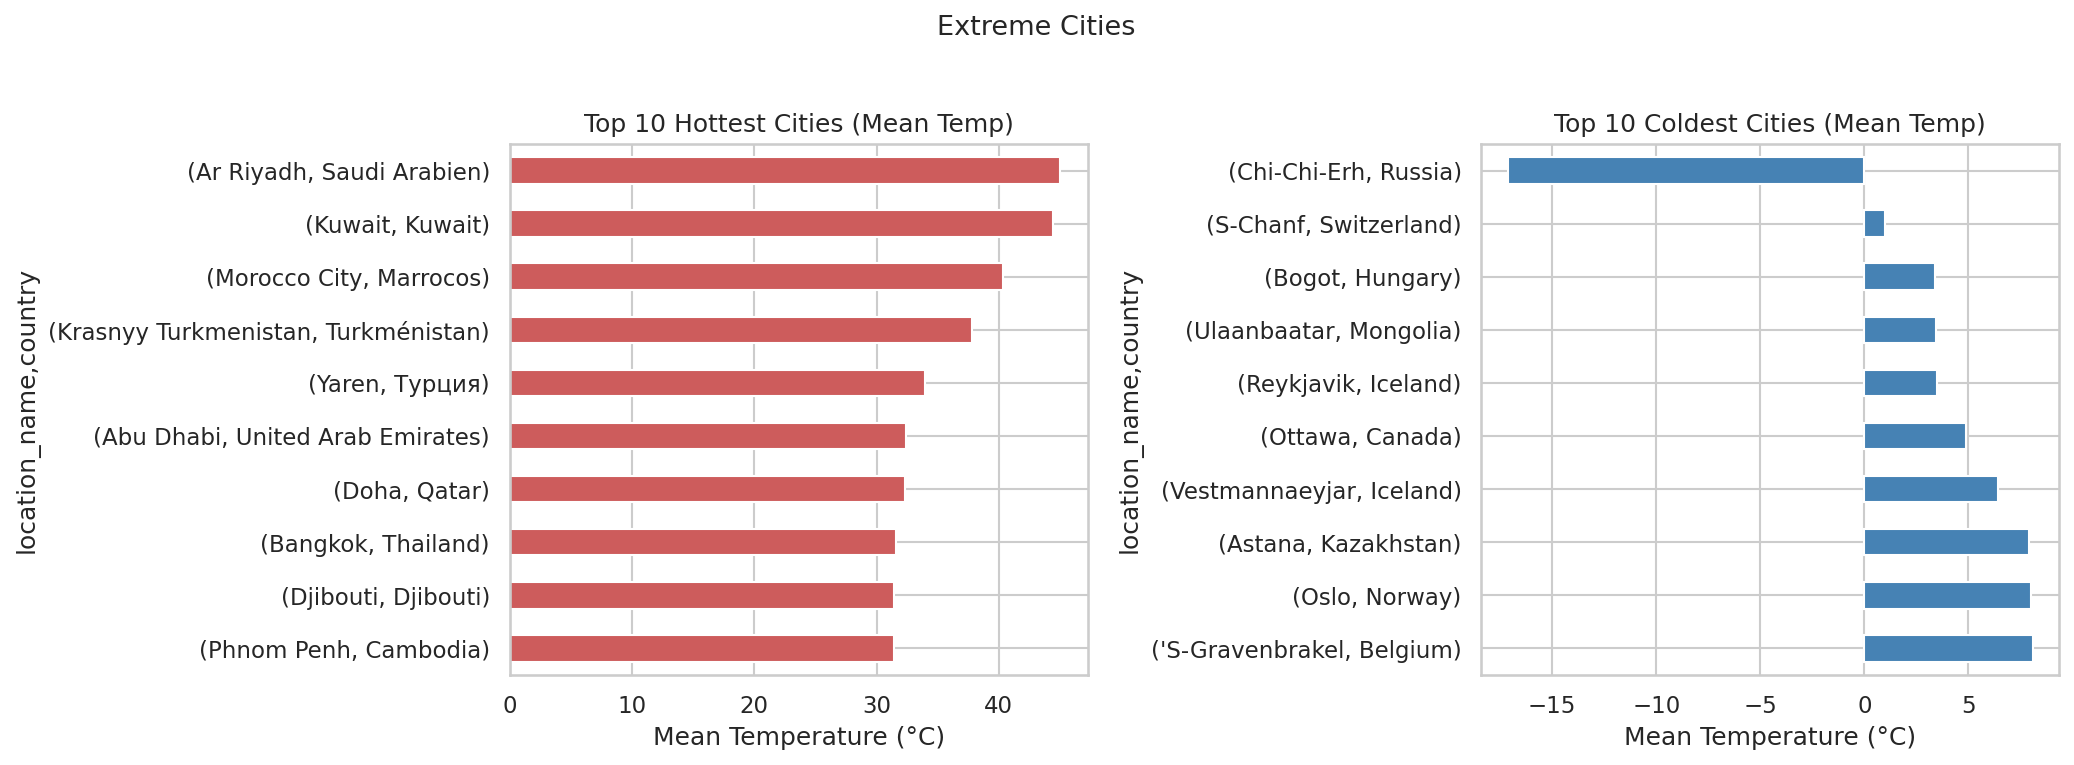

In [ ]:
display(Image(filename=os.path.join(FIGS, 'geo_extreme_cities.png')))

The hottest cities are in the Middle East and North Africa (desert climates), while the coldest are at high northern latitudes.

---
# Summary

| Analysis | Key Findings |
|---|---|
| **Climate** | Northern Hemisphere shows larger seasonal amplitude; tropical zones are stable |
| **Environmental** | Humidity suppresses ozone (r=−0.41); temperature drives ozone production above 25°C |
| **Features** | Latitude (#1) and UV index (#2) are the top temperature predictors across all methods |
| **Spatial** | Clear latitudinal temperature gradient; PM2.5 hotspots in South Asia and Africa |
| **Geographical** | Africa hottest (25.4°C), Europe coldest (13.4°C); Asia highest pollution; opposite seasonality between hemispheres |